## Logistic Regression Implementation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
from sklearn.datasets import make_classification

In [3]:
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=4)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [5]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)


In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
score = accuracy_score(y_test, y_pred)
print(score)
print(confusion_matrix(y_pred, y_test))
print(classification_report(y_pred, y_test))

0.915
[[106   9]
 [  8  77]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       115
           1       0.90      0.91      0.90        85

    accuracy                           0.92       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.92      0.92      0.92       200



## Hyperparameter Tuning And Cross Validation with GridSearchCV

In [7]:
model = LogisticRegression()
penalty = ['l1', 'l2', 'elasticnet', 'none']
c_values = [0.01, 0.1, 1, 10, 100]
solvers = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
param_grid = {'penalty': penalty, 'C': c_values, 'solver': solvers}

In [8]:
from sklearn.model_selection import GridSearchCV
grid_model = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=10)
grid_model.fit(X_train, y_train)
grid_model.fit(X_train, y_train)

c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [9]:
grid_model.best_params_

{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}

In [10]:
grid_model.best_score_

np.float64(0.89875)

In [11]:
y_pred_grid = grid_model.predict(X_test)
score_grid = accuracy_score(y_test, y_pred_grid)
print(score_grid)
print(confusion_matrix(y_pred_grid, y_test))
print(classification_report(y_pred_grid, y_test))

0.91
[[103   7]
 [ 11  79]]
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       110
           1       0.92      0.88      0.90        90

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



## Hyperparameter Tuning with RandomizedSearchCV

In [12]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
model = LogisticRegression()
randomcv=RandomizedSearchCV(estimator=model,param_distributions=param_grid,cv=5,scoring='accuracy')
randomcv.fit(X_train,y_train)

c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
20 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages

,estimator,LogisticRegression()
,param_distributions,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [15]:
randomcv.best_params_

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 0.01}

In [16]:
randomcv.best_score_

np.float64(0.8950000000000001)

In [18]:
y_pred=randomcv.predict(X_test)
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

0.91
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       108
           1       0.93      0.87      0.90        92

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200

[[102   6]
 [ 12  80]]


## Logistic Regression For Multiclass Classification Problem

In [19]:
X, y = make_classification(n_samples=1000, n_features=10,n_informative=3, n_classes=3, random_state=15)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=12)
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression(multi_class='ovr')
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)
y_pred

c:\Users\yaaar\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


array([1, 1, 2, 2, 2, 1, 0, 2, 1, 0, 1, 2, 0, 0, 0, 1, 0, 2, 1, 2, 0, 1,
       2, 2, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 1,
       1, 2, 1, 0, 0, 0, 0, 1, 2, 1, 0, 2, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       2, 0, 0, 2, 1, 1, 2, 2, 0, 1, 2, 1, 2, 0, 2, 0, 2, 0, 1, 2, 1, 1,
       1, 1, 2, 2, 2, 2, 0, 2, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 1,
       1, 0, 1, 2, 1, 1, 2, 2, 1, 2, 2, 2, 0, 1, 0, 1, 0, 2, 1, 0, 0, 1,
       1, 1, 2, 1, 2, 0, 0, 0, 0, 2, 1, 2, 2, 2, 0, 0, 1, 2, 1, 0, 1, 0,
       2, 2, 2, 0, 1, 1, 1, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 2, 1, 2, 0,
       2, 2, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 2, 0, 1, 1, 0, 0, 0, 2, 2,
       0, 0, 2, 1, 1, 0, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 0, 0, 2, 2, 2,
       1, 0, 0, 2, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 0, 0, 1, 2, 0, 2,
       0, 1, 2, 0, 0, 1, 0, 2, 1, 0, 1, 0, 0, 1, 0, 2, 1, 1, 2, 1, 2, 2,
       0, 1, 2, 0, 1, 1, 2, 0, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 2, 2, 2, 0, 0, 1, 2, 2, 0, 2, 0])

In [20]:
score=accuracy_score(y_pred,y_test)
print(score)
print(classification_report(y_pred,y_test))
print(confusion_matrix(y_pred,y_test))

0.82
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        95
           1       0.80      0.78      0.79       102
           2       0.83      0.83      0.83       103

    accuracy                           0.82       300
   macro avg       0.82      0.82      0.82       300
weighted avg       0.82      0.82      0.82       300

[[81  5  9]
 [14 80  8]
 [ 3 15 85]]


## Logistic Regression for Imbalanced Dataset

In [21]:
from collections import Counter
## imbalanced dataset
X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

<Axes: >

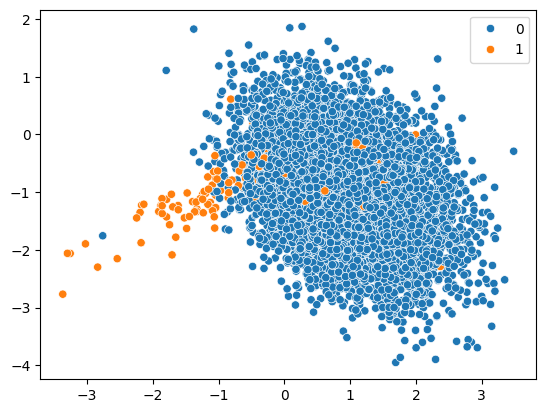

In [24]:
import seaborn as sns
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [26]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
penalty=['l1', 'l2', 'elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
class_weight=[{0:w,1:y} for w in [1,10,50,100] for y in [1,10,50,100]]

In [27]:
params=dict(penalty=penalty,C=c_values,solver=solver,class_weight=class_weight)
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv)